In [1]:
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from models import Restaurant, Person, Time

In [2]:
from data_loader import load_data, parse_data, find_json_files

In [3]:
DATA_PATH = r"../data/6-3-simple-data.json"
data = load_data(find_json_files(DATA_PATH)[0])

In [4]:
restaurants, people = parse_data(data)
print(f"Loaded {len(restaurants)} restaurants and {len(people)} people.")

Loaded 9 restaurants and 3 people.


In [5]:
def get_restaurants_df(restaurants: list[Restaurant]) -> pd.DataFrame:
    def convert_traffic_pattern_to_decimal(
        traffic_pattern: list[tuple[Time, float]],
    ) -> list[tuple[float, int]]:
        traffic_pattern_decimal = []
        for time, traffic in traffic_pattern:
            hour = time[0] + time[1] / 60
            traffic_pattern_decimal.append((hour, traffic))
        return traffic_pattern_decimal

    df = pd.DataFrame(
        {
            "Name": [restaurant.name for restaurant in restaurants],
            "Cuisine Type": [restaurant.cuisine_type for restaurant in restaurants],
            "Average Price": [restaurant.average_price for restaurant in restaurants],
            "Rating": [restaurant.rating for restaurant in restaurants],
            "Opening Time": [
                restaurant.available_hours[0][0] + restaurant.available_hours[0][1] / 60
                for restaurant in restaurants
            ],
            "Closing Time": [
                restaurant.available_hours[1][0] + restaurant.available_hours[1][1] / 60
                for restaurant in restaurants
            ],
            "Traffic Pattern": [
                convert_traffic_pattern_to_decimal(restaurant.traffic_pattern)
                for restaurant in restaurants
            ],
        }
    )
    return df

In [6]:
def get_people_df(people: list[Person]) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "Name": [person.name for person in people],
            "Budget": [person.budget for person in people],
            "Preference": [person.preferred_cuisines for person in people],
            "Starting Time": [
                person.available_hours[0][0] + person.available_hours[0][1] / 60
                for person in people
            ],
            "Ending Time": [
                person.available_hours[1][0] + person.available_hours[1][1] / 60
                for person in people
            ],
        }
    )
    return df

In [7]:
df_restaurants = get_restaurants_df(restaurants)
df_people = get_people_df(people)

In [8]:
def plot_restaurants_rating(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x="Rating")
    plt.title("Count of Restaurants by Rating")
    plt.xlabel("Rating")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [9]:
def plot_restaurants_price(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x="Average Price", bins=20)
    plt.title("Distribution of Average Price")
    plt.xlabel("Average Price")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [10]:
def plot_restaurants_cuisine(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, y="Cuisine Type")
    plt.title("Count of Restaurants by Cuisine Type")
    plt.xlabel("Count")
    plt.ylabel("Cuisine Type")
    plt.tight_layout()
    plt.show()

In [11]:
def plot_restaurants_hours(df: pd.DataFrame, step: float = 0.25):
    def get_closest_traffic(
        traffic_pattern: list[tuple[float, int]], time: float
    ) -> int:
        closest_traffic = min(traffic_pattern, key=lambda x: abs(x[0] - time))
        return closest_traffic[1]

    plt.figure(figsize=(12, 6))

    for _, restaurant in df.iterrows():
        name = restaurant["Name"]
        opening_time = restaurant["Opening Time"]
        closing_time = restaurant["Closing Time"]

        time_slots = np.arange(0, 24, step).tolist()

        traffic_pattern = restaurant["Traffic Pattern"]

        for time in time_slots:
            time_traffic = get_closest_traffic(traffic_pattern, time)  # [0, 100]
            color = sns.color_palette("flare", as_cmap=True)(time_traffic / 100)

            is_within_hours = False
            if opening_time <= closing_time:
                # Normal hours (e.g., 12.00 to 17.00)
                is_within_hours = opening_time <= time < closing_time
            else:
                # Overnight hours (e.g., 14.00 to 1.00)
                is_within_hours = time >= opening_time or time < closing_time

            if is_within_hours:
                plt.barh(name, step, left=time, color=color)

    plt.xlim(0, 24)
    plt.xticks(np.arange(0, 25, 1))
    plt.grid(axis="x")
    plt.title("Restaurant Opening Hours")
    plt.xlabel("Time (in decimal hours)")
    plt.ylabel("Restaurant Name")
    plt.tight_layout()
    plt.show()

In [12]:
def plot_people_budget(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x="Budget", bins=20)
    plt.title("Distribution of People by Budget")
    plt.xlabel("Budget")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [13]:
def plot_people_preference(df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    people_no = df.shape[0]
    colors = sns.color_palette("tab20", n_colors=people_no)

    lefts = defaultdict(int)
    for i, (_, person) in enumerate(df.iterrows()):
        preferences = person["Preference"]
        for preference in preferences:
            plt.barh(preference, 1, left=lefts[preference], color=colors[i])
            lefts[preference] += 1

    plt.title("Count of People by Cuisine Preference")
    plt.xlabel("Cuisine Preference")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [14]:
def plot_people_hours(df: pd.DataFrame):
    plt.figure(figsize=(12, 6))
    color = sns.color_palette(n_colors=1)[0]

    for _, person in df.iterrows():
        name = person["Name"]
        starting_time = person["Starting Time"]
        ending_time = person["Ending Time"]

        if ending_time < starting_time:
            # Overnight hours
            plt.barh(name, 24 - starting_time, left=starting_time, color=color)
            plt.barh(name, ending_time, left=0, color=color)
        else:
            # Normal hours
            plt.barh(name, ending_time - starting_time, left=starting_time, color=color)

    plt.xlim(0, 24)
    plt.xticks(np.arange(0, 25, 1))
    plt.grid(axis="x")
    plt.title("Available Hours of People")
    plt.xlabel("Time (in decimal hours)")
    plt.ylabel("Person Name")
    plt.tight_layout()
    plt.show()

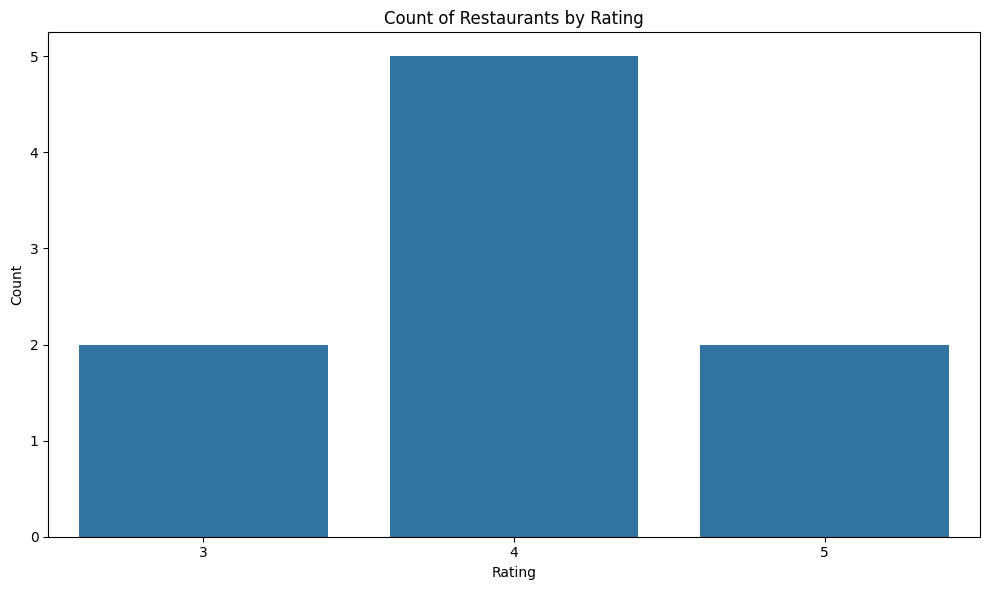

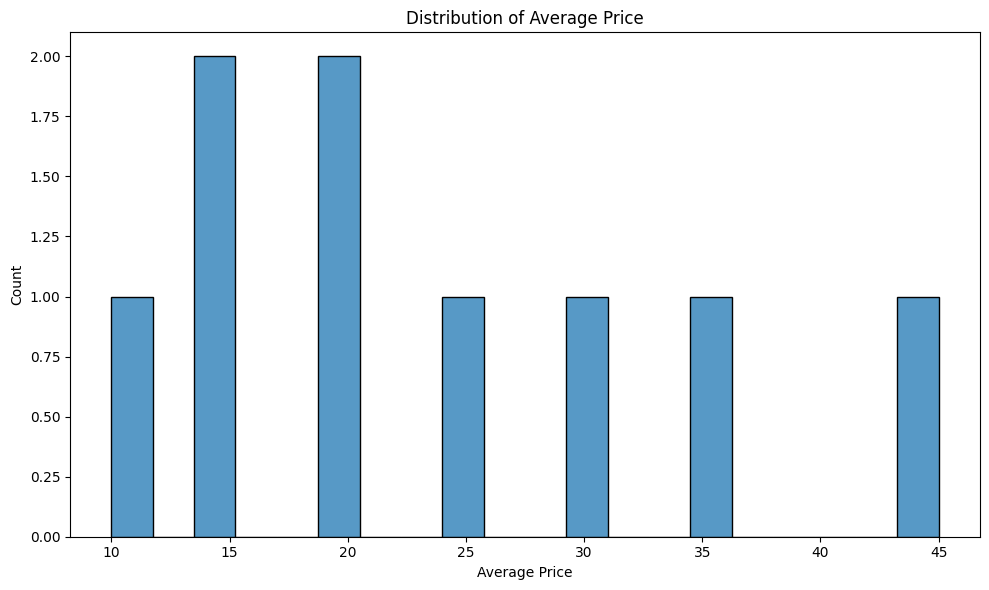

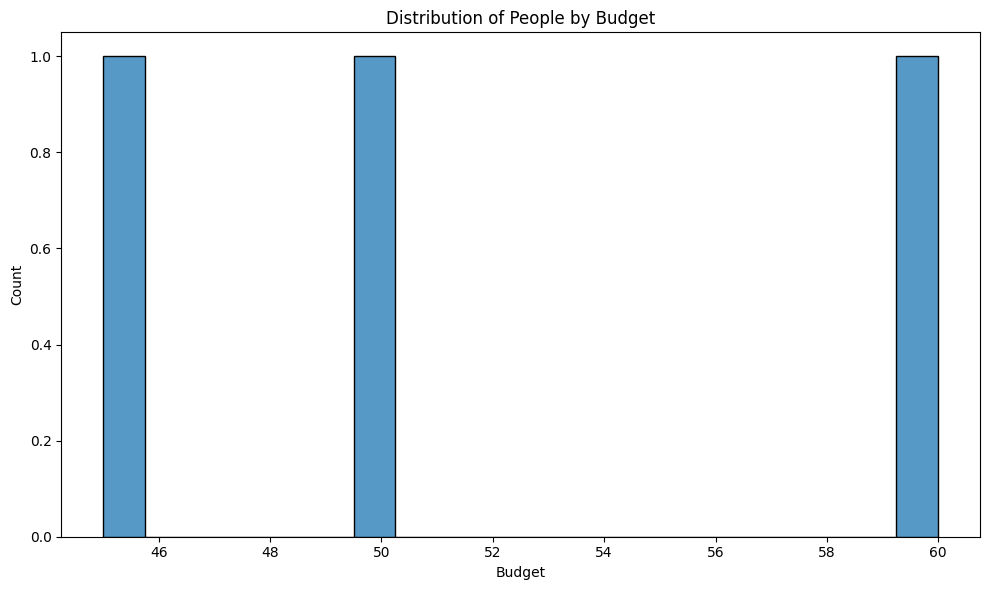

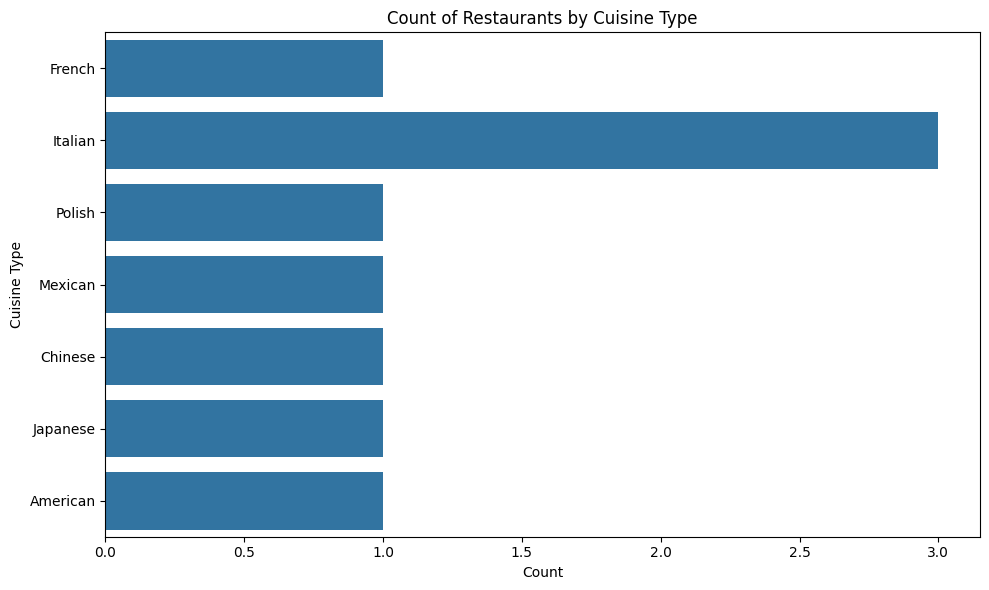

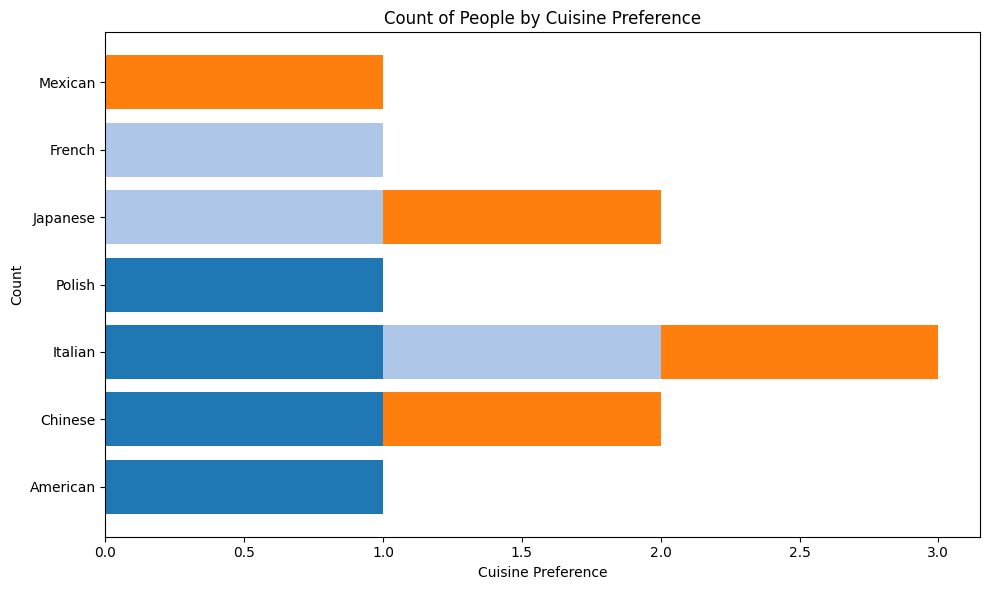

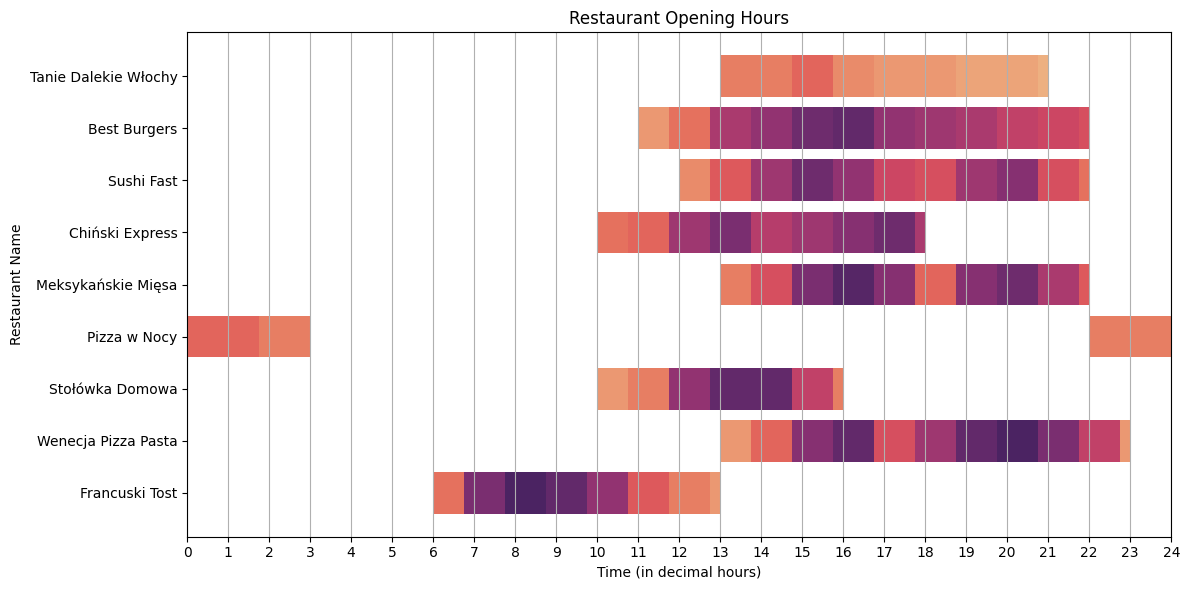

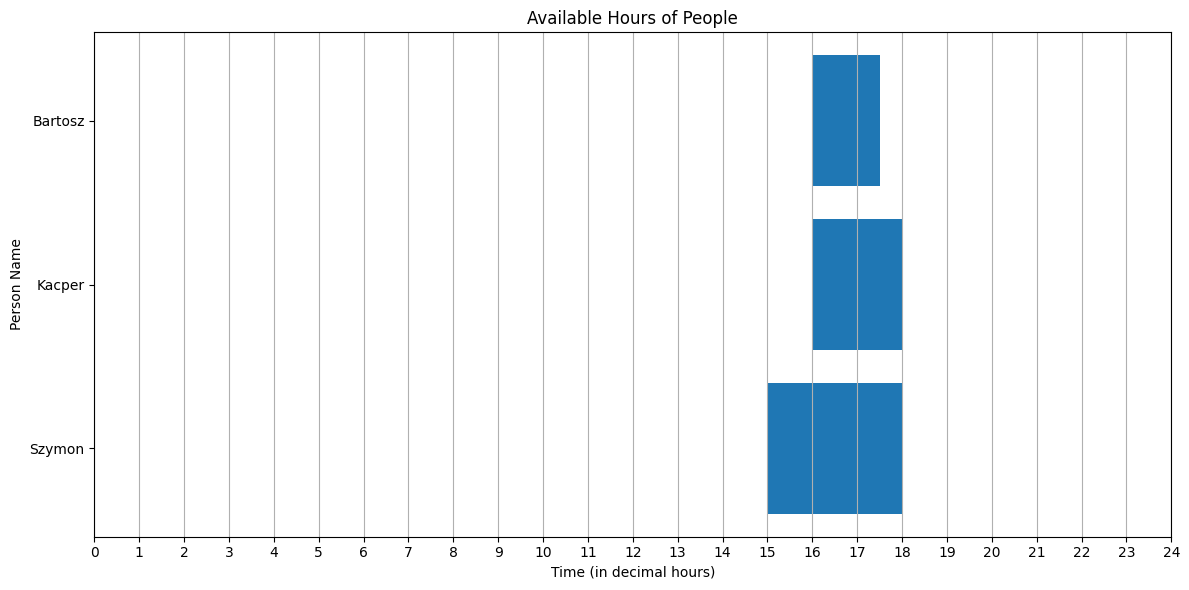

In [15]:
plot_restaurants_rating(df_restaurants)

plot_restaurants_price(df_restaurants)
plot_people_budget(df_people)

plot_restaurants_cuisine(df_restaurants)
plot_people_preference(df_people)

plot_restaurants_hours(df_restaurants)
plot_people_hours(df_people)